# UBDS 2026: Basic Python
## Day 3: Pandas & Matplotlib

### Topics covered
1. Learn to handle **large datasets** using Pandas.
2. Perform **basic numerical analyses** with NumPy.
3. Visualise data using Matplotlib.
4. Explore real-world biological data from the **AnAge database**.

## Resources
### Pandas documentation: https://pandas.pydata.org/docs/user_guide/index.html
### Graph examples: https://python-graph-gallery.com


### We will use the AnAge dataset ('anage_data.tsv'); a curated database of ageing and life history in animals, including extensive longevity records

# Step 0: Import the tools we need

- `pandas` helps us work with tables of data, given the alias; pd
- `numpy` is needed to work with numerical data, given the alias; np
- `matplotlib` helps us make plots, given the alias; plt

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load the Dataset 

- Make sure the file is in the same folder as your notebook

In [3]:
# Read in the dataframe - use separator=tab as we have a tab separated file
df = pd.read_csv("anage_data.tsv", sep='\t') 

# Filter the dataframe columns to the ones we are interested in
df = df[['Class', 'Order', 'Family', 'Genus', 'Species', 'Common name', 'Female maturity (days)', 'Male maturity (days)', 'Gestation/Incubation (days)', 'Weaning (days)', 'Litter/Clutch size', 'Litters/Clutches per year', 'Inter-litter/Interbirth interval', 'Birth weight (g)', 'Weaning weight (g)', 'Adult weight (g)', 'Growth rate (1/days)', 'Maximum longevity (yrs)', 'Source', 'Specimen origin', 'Sample size', 'Data quality', 'IMR (per yr)', 'MRDT (yrs)', 'Metabolic rate (W)', 'Body mass (g)', 'Temperature (K)']]
df.head(5)  # Show first 5 rows

,Class,Order,Family,Genus,Species,Common name,Female maturity (days),Male maturity (days),Gestation/Incubation (days),Weaning (days),...,Maximum longevity (yrs),Source,Specimen origin,Sample size,Data quality,IMR (per yr),MRDT (yrs),Metabolic rate (W),Body mass (g),Temperature (K)
0,Polychaeta,Sabellida,Siboglinidae,Escarpia,laminata,Escarpia laminata,NaN,NaN,NaN,NaN,...,300.00,1466,wild,medium,acceptable,NaN,NaN,NaN,NaN,NaN
1,Polychaeta,Sabellida,Siboglinidae,Lamellibrachia,luymesi,Lamellibrachia luymesi,NaN,NaN,NaN,NaN,...,250.00,652,wild,small,acceptable,NaN,NaN,NaN,NaN,NaN
2,Polychaeta,Sabellida,Siboglinidae,Seepiophila,jonesi,Seepiophila jonesi,NaN,NaN,NaN,NaN,...,300.00,1467,wild,small,acceptable,NaN,NaN,NaN,NaN,NaN
3,Arachnida,Araneae,Theridiidae,Latrodectus,hasselti,Australian redback spider,NaN,NaN,NaN,NaN,...,NaN,NaN,unknown,medium,low,NaN,NaN,NaN,NaN,NaN
4,Branchiopoda,Diplostraca,Daphniidae,Daphnia,pulicaria,Daphnia,NaN,NaN,NaN,NaN,...,0.19,NaN,unknown,medium,acceptable,NaN,NaN,NaN,NaN,NaN


# EXERCISE 1 

1. What happens if you forget to specify sep='\t' when reading a tab delimited dataset?
2. As well as the head() method there is a tail() method. What do you think it does? 
3. Both methods accept a single numeric parameter. What do you think it does?

# Step 2: Explore the Dataset
- Get basic information about the dataset

In [4]:
# How many rows?
print("Dataset length: ", len(df))

# How many rows and columns?
print("Dataset shape:", df.shape)

# How many cells in the table?
print("Dataset size: ", df.size)

# Column names
print("Columns:", df.columns.tolist())

# What are the data types of the columns?
print("Column data types: ", df.dtypes)

# Quick statistics of numeric columns
df.describe()

# Check how many Species are available in the dataset 
Species = df['Common name'].to_list()
print("Number of species: ", len(set(Species)))

# Check how many Orders are available in the dataset 
Order = df['Order'].to_list()
print("Number of orders: ", len(set(Order)))

# Longest lived species 
print(df.loc[df['Maximum longevity (yrs)'].idxmax()])

Dataset length:  4645
Dataset shape: (4645, 27)
Dataset size:  125415
Columns: ['Class', 'Order', 'Family', 'Genus', 'Species', 'Common name', 'Female maturity (days)', 'Male maturity (days)', 'Gestation/Incubation (days)', 'Weaning (days)', 'Litter/Clutch size', 'Litters/Clutches per year', 'Inter-litter/Interbirth interval', 'Birth weight (g)', 'Weaning weight (g)', 'Adult weight (g)', 'Growth rate (1/days)', 'Maximum longevity (yrs)', 'Source', 'Specimen origin', 'Sample size', 'Data quality', 'IMR (per yr)', 'MRDT (yrs)', 'Metabolic rate (W)', 'Body mass (g)', 'Temperature (K)']
Column data types:  Class                                object
Order                                object
Family                               object
Genus                                object
Species                              object
Common name                          object
Female maturity (days)              float64
Male maturity (days)                float64
Gestation/Incubation (days)         fl

# EXERCISE 2

1. Name the species with the largest body mass.
2. What is the largest litter size?
3. What is the shortest lived species?

# Step 3: Accessing the data
- Selecting columns and rows

In [30]:
# Select one column
lifespan = df['Maximum longevity (yrs)']
print(lifespan.head())

# Select multiple columns
subset = df[['Common name', 'Maximum longevity (yrs)', 'Body mass (g)']]
subset.head()

# Select rows by index
print(df.iloc[0:5])

# Select rows by condition (species with max longevity > 100)
long_lived = df[df['Maximum longevity (yrs)'] > 100]
long_lived[['Common name', 'Maximum longevity (yrs)']]

0    300.00
1    250.00
2    300.00
3       NaN
4      0.19
Name: Maximum longevity (yrs), dtype: float64
          Class        Order        Family           Genus    Species  \
0    Polychaeta    Sabellida  Siboglinidae        Escarpia   laminata   
1    Polychaeta    Sabellida  Siboglinidae  Lamellibrachia    luymesi   
2    Polychaeta    Sabellida  Siboglinidae     Seepiophila     jonesi   
3     Arachnida      Araneae   Theridiidae     Latrodectus   hasselti   
4  Branchiopoda  Diplostraca    Daphniidae         Daphnia  pulicaria   

                 Common name  Female maturity (days)  Male maturity (days)  \
0          Escarpia laminata                     NaN                   NaN   
1     Lamellibrachia luymesi                     NaN                   NaN   
2         Seepiophila jonesi                     NaN                   NaN   
3  Australian redback spider                     NaN                   NaN   
4                    Daphnia                     NaN             

,Common name,Maximum longevity (yrs)
0,Escarpia laminata,300.0
1,Lamellibrachia luymesi,250.0
2,Seepiophila jonesi,300.0
174,Olm,102.0
1840,Greenland shark,392.0
1853,Lake sturgeon,152.0
1860,White sturgeon,104.0
1862,Beluga sturgeon,118.0
2259,Bowhead whale,211.0
2265,Blue whale,110.0


# EXERCISE 3: What happens if you:

1. List the columns you want out of order from the way they appear in the file?
2. Put the same column name in twice?
3. Put in a non-existing column name? (a.k.a Typo)

# Step 4: Filtering data
- Filter the rows of the dataframe
- Print the values to get the answer for each filter

In [6]:
# Filter by the index of each row - the range is from ro 1 to row 5
df_filtered = df[1:5]

# Using a criteria to filter rows 
df_old = df[df['Maximum longevity (yrs)'] > 30]

# We can filter by more than one attribute
df_old_and_fat = df[(df['Maximum longevity (yrs)'] > 30) & (df['Body mass (g)'] > 30000)]


# EXERCISE 4
1. What happens if we ask for a single row instead of a range?
2. What species have a temperature greater than 300K and a metabolic rate greater than 200W?

# Step 5: Handling missing data
- print the values to get the answers

In [8]:
# Check for missing values
missing = df.isna().sum()

# Drop rows with missing MaxLongevity or BodyWeight
df_clean = df.dropna(subset=['Maximum longevity (yrs)', 'Body mass (g)'])

print("Rows after cleaning:", df_clean.shape)

Rows after cleaning: (547, 27)
Class                                  0
Order                                  0
Family                                 0
Genus                                  0
Species                                0
Common name                            0
Female maturity (days)              2160
Male maturity (days)                2740
Gestation/Incubation (days)         2810
Weaning (days)                      3877
Litter/Clutch size                  2552
Litters/Clutches per year           3341
Inter-litter/Interbirth interval    3880
Birth weight (g)                    3415
Weaning weight (g)                  4261
Adult weight (g)                     982
Growth rate (1/days)                4086
Maximum longevity (yrs)              504
Source                               574
Specimen origin                        0
Sample size                            0
Data quality                           0
IMR (per yr)                        4602
MRDT (yrs)                

# EXERCISE 5

1. How many missing values are there in each column?
2. How many rows remain after removing missing values?
3. What happens if you drop rows based only on one column instead of two?

# Step 6: Working with large amounts of data with groupby
- When we want summary statistics for different groups in our dataframe
- For example calculating the mean lifespan per taxonomic class

## Tip:
- GroupBy is very powerful in Pandas for summarizing data by categories.

In [12]:
# Group by Class and calculate mean MaxLongevity
mean_lifespan = df_clean.groupby('Class')['Maximum longevity (yrs)'].mean()
print(mean_lifespan)

Class
Amphibia    21.000000
Aves        18.036527
Mammalia    15.058286
Reptilia    33.528571
Name: Maximum longevity (yrs), dtype: float64


# EXERCISE 6: GroupBy
1. Which class has the highest average lifespan?
2. How many species are in each class?
3. What is the average body mass per class?

# Step 7: Simple Numerical Operations with NumPy
- Convert lifespan to a NumPy array for calculations

In [9]:
# Convert lifespan to a NumPy array for calculations
lifespan_array = df_clean['Maximum longevity (yrs)'].to_numpy()

print("Mean lifespan:", np.mean(lifespan_array))
print("Median lifespan:", np.median(lifespan_array))
print("Standard deviation:", np.std(lifespan_array))

Mean lifespan: 16.614076782449725
Median lifespan: 13.0
Standard deviation: 12.841577355371681


# EXERCISE 7: Numpy operations

1. What is the mean lifespan of the dataset?
2. Is the median higher or lower than the mean? What does this suggest?
3. What happens to the standard deviation if you remove extreme values? Use row filtering to remove the longest lived and shortest lived species.

# Step 8: Visualizing Data with Matplotlib
- The histogram is a simple yet useful plot for understanding  the distribution of values in a column. 

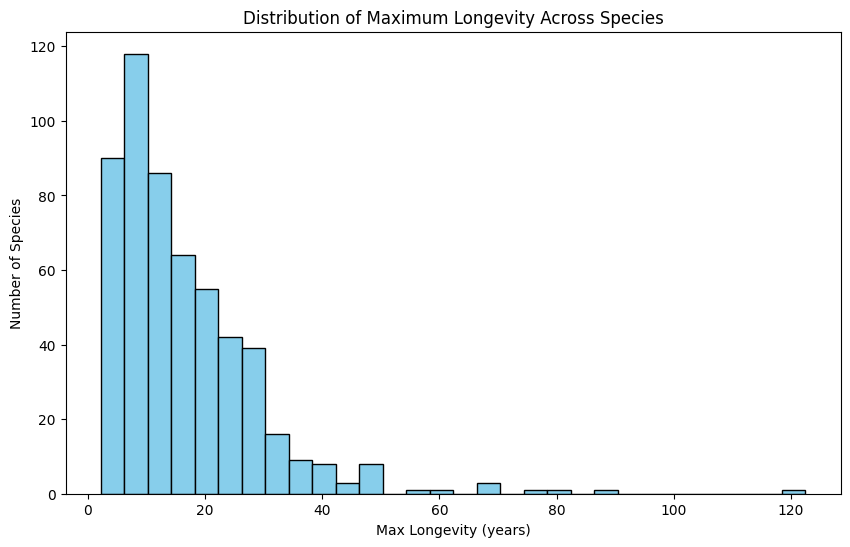

In [14]:
# Histogram of maximum lifespans
plt.figure(figsize=(10,6))
plt.hist(df_clean['Maximum longevity (yrs)'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Maximum Longevity Across Species")
plt.xlabel("Max Longevity (years)")
plt.ylabel("Number of Species")
plt.show()

# EXERCISE 8: Histogram (Matplotlib)

1. What does the shape of the distribution look like (e.g. skewed or normal)?
2. What happens if you increase or decrease the number of bins?
3. Which lifespan range contains the most species?

# Step 9: Scatter Plot
- Scatter plots allow us to compare values from two columns against each other. 

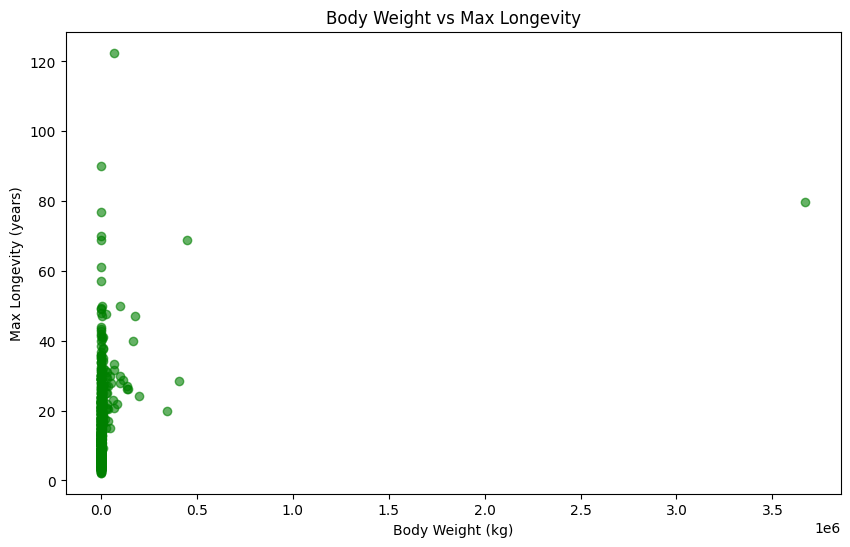

In [12]:
# Scatter Plot - Body Weight vs Max Longevity
plt.figure(figsize=(10,6))
plt.scatter(df_clean['Body mass (g)'], df_clean['Maximum longevity (yrs)'], alpha=0.6, color='green')
plt.title("Body Weight vs Max Longevity")
plt.xlabel("Body Weight (kg)")
plt.ylabel("Max Longevity (years)")
plt.show()

# EXERCISE 9.1: Simple Scatter

1. Do larger animals tend to live longer?
2. Are there any obvious outliers?
3. What happens if you change the transparency (alpha)?

# Improving our figures
- Adding annotations with colour and labelling certain datapoints makes our figures more informative
- Visualising points on the log scale can help by separating our data and making it more understandable

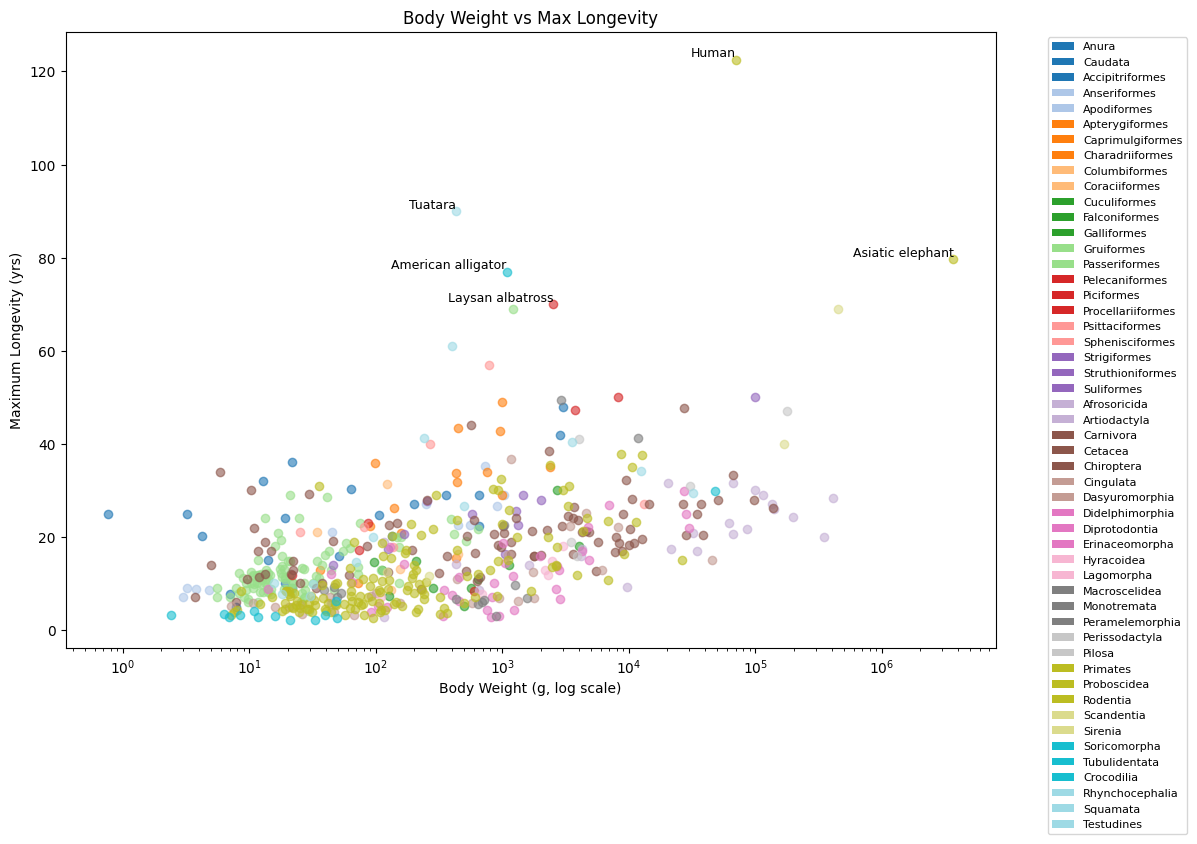

In [13]:
# Step 8.2: Scatter Plot - colored by Order and label longest-lived species
plt.figure(figsize=(12,8))

# Get unique orders and assign colors <- Colour each point by the phylogenetic tree
orders = df_clean['Order'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(orders)))
order_color_map = dict(zip(orders, colors))

# Plot each point with color based on Order
for idx, row in df_clean.iterrows():
    plt.scatter(row['Body mass (g)'], row['Maximum longevity (yrs)'], 
                color=order_color_map[row['Order']], alpha=0.6)

# Label the top 5 longest-lived species
top_longest = df_clean.nlargest(5, 'Maximum longevity (yrs)')
for idx, row in top_longest.iterrows():
    plt.text(row['Body mass (g)'], row['Maximum longevity (yrs)'], 
             row['Common name'], fontsize=9, ha='right', va='bottom')

# Plot the layers for the Matplotlib figure - Title & Axis 
plt.xscale('log')  # log scale for better visualization
plt.title("Body Weight vs Max Longevity")
plt.xlabel("Body Weight (g, log scale)")
plt.ylabel("Maximum Longevity (yrs)")

# Create a legend for Orders
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=order) for order, color in order_color_map.items()]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.show()

# EXERCISE 9.2: Annotated scatter plot

1. Which order contains the longest-lived species?
2. Why is a log scale useful for body weight?
3. What happens if you label more than 5 species?
4. Can you identify any clusters of related species?

# Step 10: Do heavier animals really live longer?
- We can add a regression live to out plots to calculate the correlation between two variables. 

Correlation between body weight and longevity: 0.27


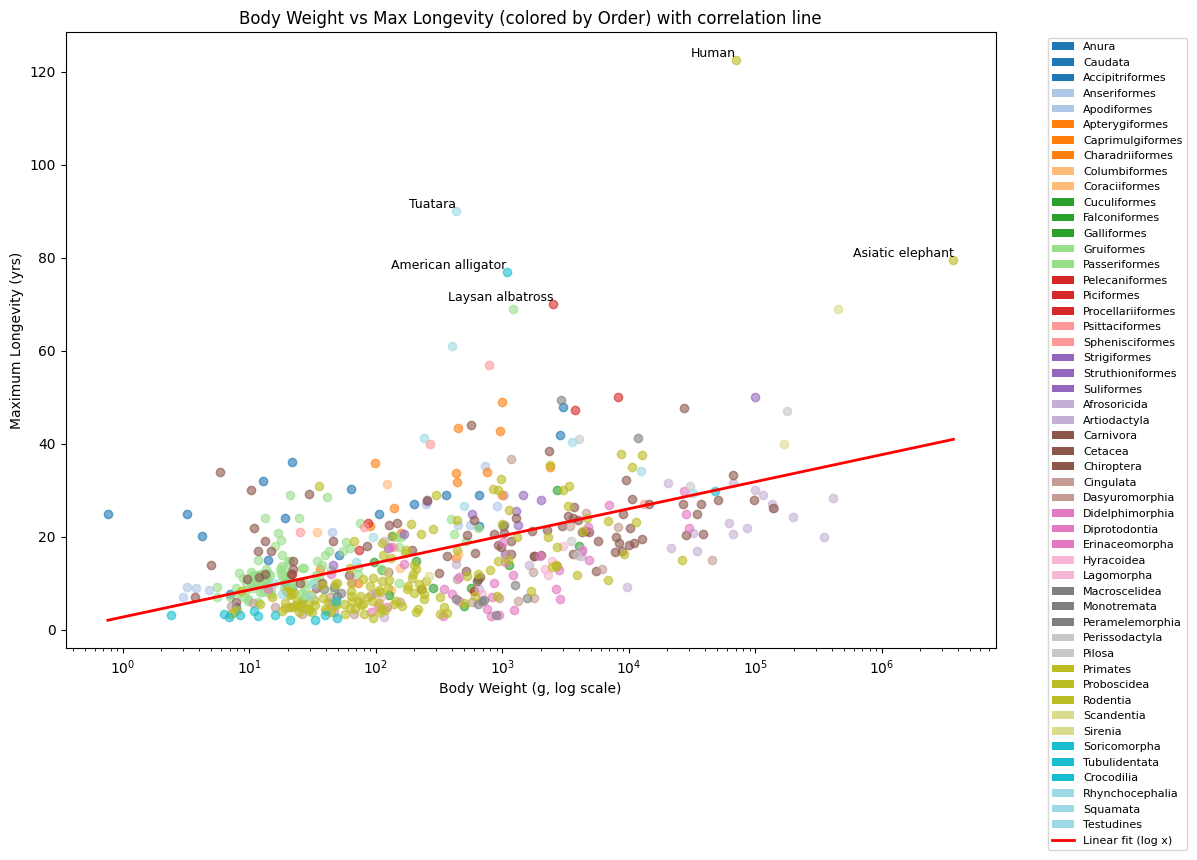

In [14]:
correlation = df_clean['Body mass (g)'].corr(df_clean['Maximum longevity (yrs)'])
print(f"Correlation between body weight and longevity: {correlation:.2f}")

# Prepare x and y
x = df_clean['Body mass (g)']
y = df_clean['Maximum longevity (yrs)']

# Take log of x for fitting (because x-axis is log scale)
log_x = np.log10(x)

# Linear regression in log space: y = slope * log10(x) + intercept
slope, intercept = np.polyfit(log_x, y, 1)

# Create points for the regression line
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = slope * np.log10(x_fit) + intercept

# --- Plot ---
plt.figure(figsize=(12,8))

# Scatter points colored by Order
for idx, row in df_clean.iterrows():
    plt.scatter(row['Body mass (g)'], row['Maximum longevity (yrs)'], 
                color=order_color_map[row['Order']], alpha=0.6)

# Label the top 5 longest-lived species
top_longest = df_clean.nlargest(5, 'Maximum longevity (yrs)')
for idx, row in top_longest.iterrows():
    plt.text(row['Body mass (g)'], row['Maximum longevity (yrs)'], 
             row['Common name'], fontsize=9, ha='right', va='bottom')

# Plot the regression line
plt.plot(x_fit, y_fit, color='red', linewidth=2, label=f'Linear fit (log x)')

plt.xscale('log')  # log scale for better visualization
plt.title("Body Weight vs Max Longevity (colored by Order) with correlation line")
plt.xlabel("Body Weight (g, log scale)")
plt.ylabel("Maximum Longevity (yrs)")

# Legend for both orders and regression line
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=order) for order, color in order_color_map.items()]
plt.legend(handles=legend_elements + [plt.Line2D([0], [0], color='red', lw=2, label='Linear fit (log x)')],
           bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.show()

# Step 11: What is the distribution of birth weights for animals which live longer than 5 years? 
- Group the distribution by taxonomic class. 

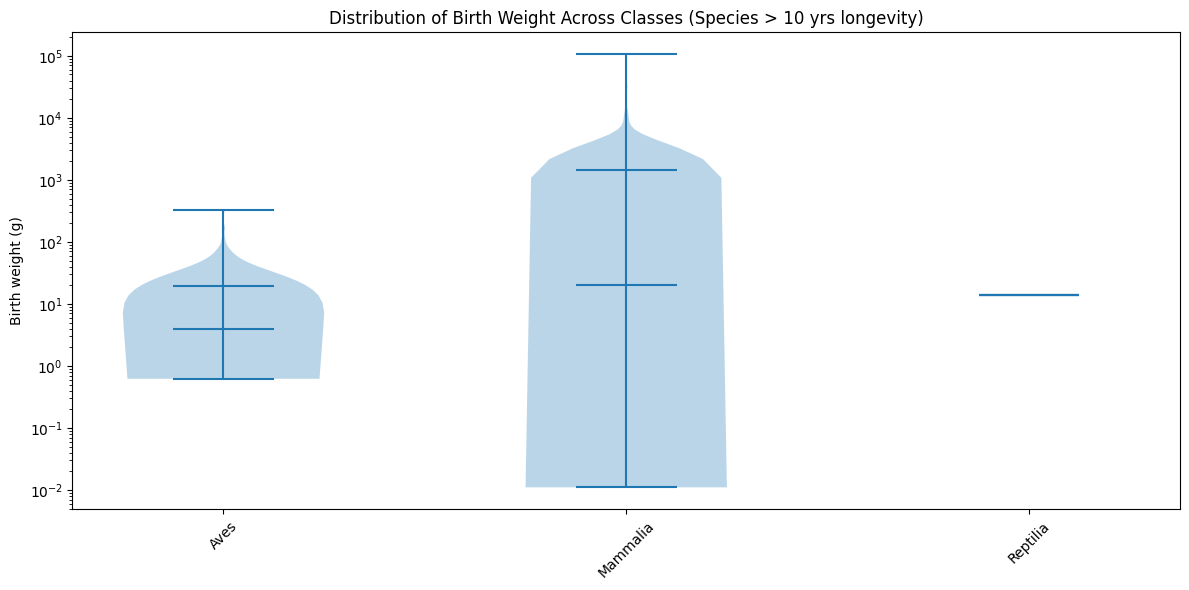

In [15]:
# Filter for species with longevity > 5 years
long_lived = df_clean[df_clean['Maximum longevity (yrs)'] > 5]

# Prepare data for each Class
classes = long_lived['Class'].unique()
data = []

filtered_classes = []
for cls in classes:
    birth_weights = long_lived[long_lived['Class'] == cls]['Birth weight (g)'].dropna()
    if len(birth_weights) > 0:  # Only keep non-empty arrays
        data.append(birth_weights)
        filtered_classes.append(cls)

# Create the violin plot
plt.figure(figsize=(12,6))
plt.violinplot(data, showmeans=True, showmedians=True)

# Set x-ticks to class names
plt.xticks(ticks=np.arange(1, len(filtered_classes)+1), labels=filtered_classes, rotation=45)
plt.yscale('log')
plt.ylabel("Birth weight (g)")
plt.title("Distribution of Birth Weight Across Classes (Species > 10 yrs longevity)")
plt.tight_layout()
plt.show()

# Step 11: Challenge for Students
## For each of the following visualise the answer and summarise the results in 2-3 sentences. 
- Which Class of animals has the highest average longevity?
- Does litter size correlate with longevity?
- Which Order of animals has the highest average longevity?
- Create a scatter plot of Body Mass vs Maximum Longevity only for mammals. What is the correlation?
- Identify species with unexpected lifespans (e.g., small animals that live unusually long).
- Compare birds and mammals in terms of average lifespan using a bar chart.
- Does longevity always correlate with Female (or Male) maturity (days)? Identify species who grow up fast.